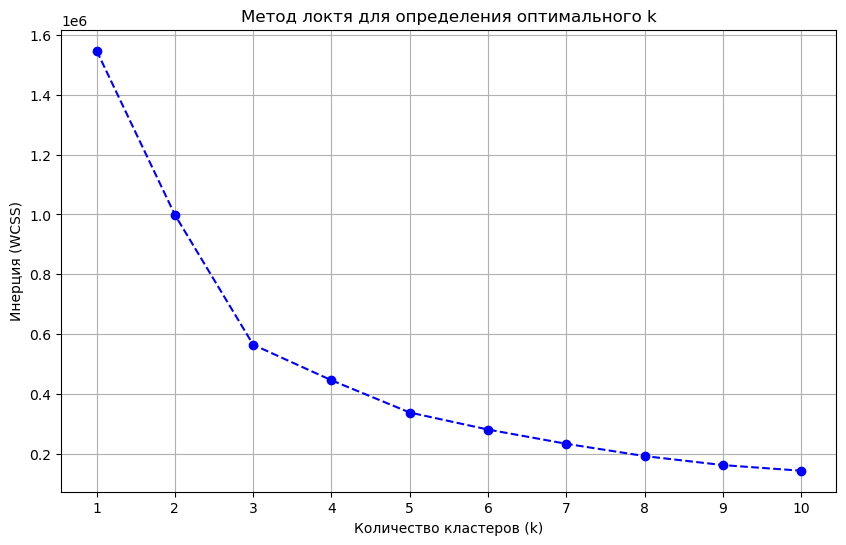

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Загрузка данных
df = pd.read_csv('bitcoin_clustered_users.csv')

# 2. Подготовка признаков (берем те же, что были в K-Means)
X = df[['Total_Received_BTC', 'Total_Tx']].copy()

# 3. Логарифмирование и масштабирование
# Без логарифма "локоть" будет смазан из-за гигантских сумм у бирж
X_log = np.log1p(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 4. Расчет инерции для разного количества кластеров
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# 5. Построение графика
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='b')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Инерция (WCSS)')
plt.title('Метод локтя для определения оптимального k')
plt.xticks(k_range)
plt.grid(True)
plt.show()